# 05A_scan_data.ipynb

Notebook này làm đúng workflow sau:

1. Đọc toàn bộ file dữ liệu FER-2013 dạng `emotion, pixels, Usage`
2. Quét toàn bộ ảnh và gắn 4 mức:
   - `remove`
   - `review`
   - `suspect`
   - `ok`
3. Xuất ra **2 file CSV**:

### File 1: bản đầy đủ
Gồm các cột:
`row_id, emotion, Usage, flag, reason, pixel_count, mean, std, min, max, unique_count, zero_ratio, white_ratio, entropy`

Mục đích:
- dùng để xem chi tiết
- xem ảnh theo `row_id`
- cân nhắc có nên loại hay không

### File 2: bản rút gọn để xóa thủ công
Gồm các cột:
`row_id, emotion, Usage`

Mục đích:
- đây là danh sách các dòng đang bị gắn cờ (`remove/review/suspect`)
- bạn sẽ mở file này lên và **xóa bớt những dòng mà bạn quyết định giữ lại**
- sau cùng, file này sẽ chỉ còn lại các dòng cần remove thật sự
- lúc train, bạn chỉ cần đọc file này rồi bỏ các `row_id` tương ứng

**Notebook này không clean tự động.**


## 1. Import thư viện

In [132]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)


## 2. Cấu hình

In [133]:
DATA_PATH = '../../data/train.csv'   
OUTPUT_DIR = '../../data/cleaned_data' 
IMAGE_SIZE = 48
PIXEL_COUNT = IMAGE_SIZE * IMAGE_SIZE

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR)


Output dir: ../../data/cleaned_data


## 3. Đọc dữ liệu

Yêu cầu file đầu vào phải có 3 cột:
- `emotion`
- `pixels`
- `Usage`


In [134]:
def load_data(path):
    path = str(path)
    if path.lower().endswith('.csv'):
        df = pd.read_csv(path)
    elif path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        raise ValueError('Chỉ hỗ trợ .csv hoặc .xlsx/.xls')

    required_cols = {'emotion', 'pixels', 'Usage'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Thiếu cột: {missing}')

    df = df.copy()
    df['row_id'] = np.arange(len(df))
    return df

df = load_data(DATA_PATH)
print('Shape:', df.shape)
display(df.head())


Shape: (28709, 4)


,emotion,pixels,Usage,row_id
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,0
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,1
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,2
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,3
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,4


## 4. Parse pixel nhanh

Dùng `np.fromstring(..., sep=' ')` để parse chuỗi pixel nhanh hơn.


In [135]:
def parse_pixels_fast(pixel_str):
    return np.fromstring(str(pixel_str), dtype=np.uint8, sep=' ')

sample_arr = parse_pixels_fast(df.loc[0, 'pixels'])
print('Số pixel sample:', len(sample_arr))
print(sample_arr[:20])


Số pixel sample: 2304
[ 70  80  82  72  58  58  60  63  54  58  60  48  89 115 121 119 115 110
  98  91]


## 5. Tính entropy

Entropy dùng như một chỉ số phụ để phát hiện ảnh quá nghèo thông tin.


In [136]:
def compute_entropy(arr):
    if len(arr) == 0:
        return np.nan
    hist = np.bincount(arr, minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


## 6. Hàm scan và gắn cờ

Ta dùng 4 mức:

- `remove`: rất đáng nghi, khả năng cao nên bỏ
- `review`: nghi ngờ vừa, nên xem lại kỹ
- `suspect`: nhẹ hơn `review`, dùng để tránh bỏ sót
- `ok`: không thấy bất thường rõ ràng

Bạn có thể chỉnh ngưỡng ở đây theo ý mình.


In [137]:
def scan_image_quality(pixel_str):
    arr = parse_pixels_fast(pixel_str)

    if len(arr) != PIXEL_COUNT:
        return {
            'flag': 'remove',
            'reason': 'wrong_length',
            'pixel_count': len(arr),
            'mean': np.nan,
            'std': np.nan,
            'min': np.nan,
            'max': np.nan,
            'unique_count': 0,
            'zero_ratio': np.nan,
            'white_ratio': np.nan,
            'entropy': np.nan
        }

    mean_val = float(arr.mean())
    std_val = float(arr.std())
    min_val = int(arr.min())
    max_val = int(arr.max())
    unique_count = int(np.unique(arr).size)
    zero_ratio = float((arr == 0).mean())
    white_ratio = float((arr == 255).mean())
    entropy = compute_entropy(arr)

    # remove: nghi rất mạnh
    if std_val < 1.5:
        flag, reason = 'remove', 'very_low_std'
    elif unique_count <= 3:
        flag, reason = 'remove', 'too_few_unique_values'
    elif mean_val < 5 or zero_ratio > 0.90:
        flag, reason = 'remove', 'almost_black'
    elif mean_val > 250 or white_ratio > 0.90:
        flag, reason = 'remove', 'almost_white'
    elif entropy < 0.30:
        flag, reason = 'remove', 'very_low_entropy'

    # review: nghi trung bình
    elif std_val < 8:
        flag, reason = 'review', 'low_contrast'
    elif mean_val < 15:
        flag, reason = 'review', 'very_dark'
    elif mean_val > 240:
        flag, reason = 'review', 'very_bright'
    elif unique_count < 10:
        flag, reason = 'review', 'low_unique_values'
    elif entropy < 2.0:
        flag, reason = 'review', 'low_entropy'

    # suspect: nghi nhẹ, để tránh bỏ sót
    elif std_val < 12:
        flag, reason = 'suspect', 'slightly_low_contrast'
    elif mean_val < 25:
        flag, reason = 'suspect', 'slightly_dark'
    elif mean_val > 225:
        flag, reason = 'suspect', 'slightly_bright'
    elif unique_count < 18:
        flag, reason = 'suspect', 'slightly_low_unique_values'
    elif entropy < 3.2:
        flag, reason = 'suspect', 'slightly_low_entropy'
    else:
        flag, reason = 'ok', 'ok'

    return {
        'flag': flag,
        'reason': reason,
        'pixel_count': len(arr),
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'unique_count': unique_count,
        'zero_ratio': zero_ratio,
        'white_ratio': white_ratio,
        'entropy': entropy
    }


## 7. Quét toàn bộ dataset

In [138]:
scan_results = df['pixels'].apply(scan_image_quality)
scan_metrics_df = pd.DataFrame(scan_results.tolist())

scan_df = pd.concat([
    df[['row_id', 'emotion', 'Usage', 'pixels']].copy(),
    scan_metrics_df
], axis=1)

print('Hoàn tất scan.')
display(scan_df.head())


Hoàn tất scan.


,row_id,emotion,Usage,pixels,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy
0,0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,ok,ok,2304,117.592882,50.735357,11,210,190,0.000000,0.000000,7.316994
1,1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,ok,ok,2304,126.971354,40.854364,0,219,214,0.001736,0.000000,7.231241
2,2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,ok,ok,2304,160.814236,74.711745,0,255,254,0.015625,0.009549,7.670950
3,3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,ok,ok,2304,130.503472,59.357461,12,235,214,0.000000,0.000000,7.327695
4,4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,ok,ok,2304,97.900174,70.166311,0,241,234,0.077257,0.000000,7.488916


## 8. Thống kê kết quả

In [139]:
print('Phân bố flag:')
display(scan_df['flag'].value_counts())

print('\nPhân bố reason:')
display(scan_df['reason'].value_counts())

print('\nPhân bố theo Usage và flag:')
display(pd.crosstab(scan_df['Usage'], scan_df['flag']))


Phân bố flag:


flag
ok         28652
suspect       22
review        22
remove        13
Name: count, dtype: int64


Phân bố reason:


reason
ok                       28652
very_bright                 18
slightly_bright             13
very_low_std                12
slightly_dark                7
very_dark                    4
slightly_low_contrast        1
almost_black                 1
slightly_low_entropy         1
Name: count, dtype: int64


Phân bố theo Usage và flag:


flag,ok,remove,review,suspect
Usage,,,,
Training,28652,13,22,22


## 9. Xem nhanh các dòng bị gắn cờ

In [140]:
flagged_df = scan_df[scan_df['flag'] != 'ok'].copy()
display(flagged_df[['row_id', 'emotion', 'Usage', 'flag', 'reason', 'pixel_count', 'mean', 'std', 'min', 'max', 'unique_count', 'zero_ratio', 'white_ratio', 'entropy']].head(30))


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy
59,59,2,Training,suspect,slightly_dark,2304,22.118924,61.149661,0,255,153,0.759983,0.023003,2.238288
2059,2059,5,Training,review,very_bright,2304,245.425781,21.609312,86,255,122,0.000000,0.051215,3.504083
2171,2171,6,Training,remove,very_low_std,2304,128.302951,0.637561,127,130,4,0.000000,0.000000,1.395017
2809,2809,5,Training,review,very_bright,2304,248.087240,17.691603,151,255,86,0.000000,0.118056,2.207127
3262,3262,5,Training,review,very_bright,2304,242.844618,23.055078,85,255,123,0.000000,0.057726,3.820714
3931,3931,2,Training,review,very_bright,2304,242.663628,27.871670,119,255,122,0.000000,0.680122,2.721012
4102,4102,0,Training,suspect,slightly_dark,2304,19.451823,20.536412,0,75,75,0.168837,0.000000,5.435664
4275,4275,3,Training,review,very_bright,2304,244.990885,25.411755,127,255,114,0.000000,0.094618,2.506066
5023,5023,2,Training,suspect,slightly_bright,2304,226.347656,38.037380,44,255,172,0.000000,0.068142,5.884598
5274,5274,2,Training,suspect,slightly_bright,2304,235.333333,18.875322,196,254,59,0.000000,0.000000,5.238721


## 10. Hàm trực quan ảnh theo flag

Chỉ để bạn kiểm tra nhanh kết quả scan.


In [141]:
def show_flagged_images(dataframe, label='review', n=25, random_state=42):
    subset = dataframe[dataframe['flag'] == label].copy()
    if len(subset) == 0:
        print(f'Không có ảnh nào thuộc nhóm: {label}')
        return

    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)

    subset = subset.reset_index(drop=True)

    cols = 5
    rows = math.ceil(len(subset) / cols)

    plt.figure(figsize=(15, 3 * rows))
    for i, row in subset.iterrows():
        arr = parse_pixels_fast(row['pixels'])
        if len(arr) != PIXEL_COUNT:
            continue
        img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(
            f"id={row['row_id']}\n{row['flag']} | {row['reason']}\nemotion={row['emotion']}"
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()


## 11. Trực quan mẫu theo từng nhóm

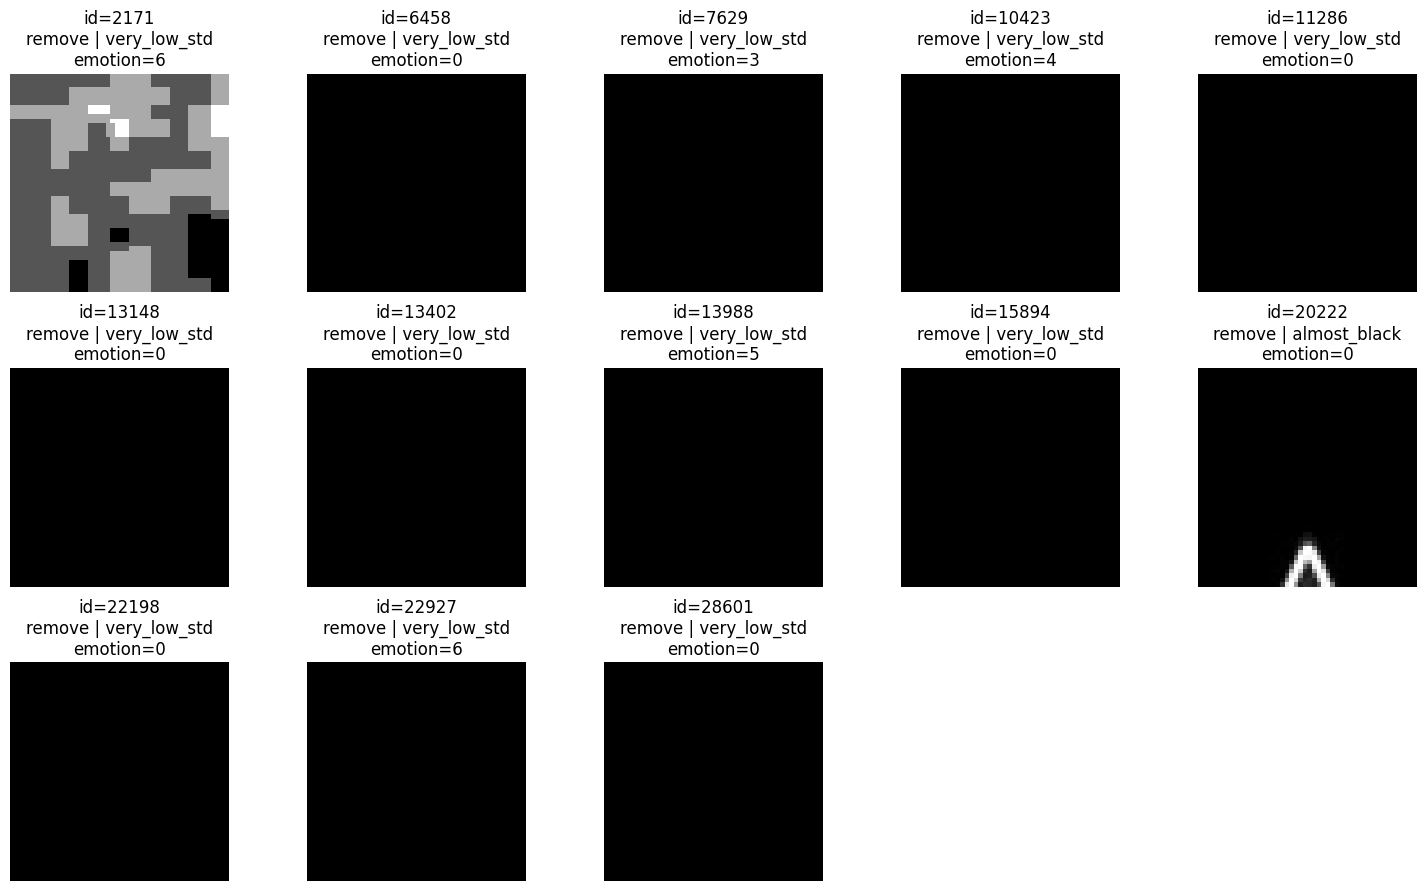

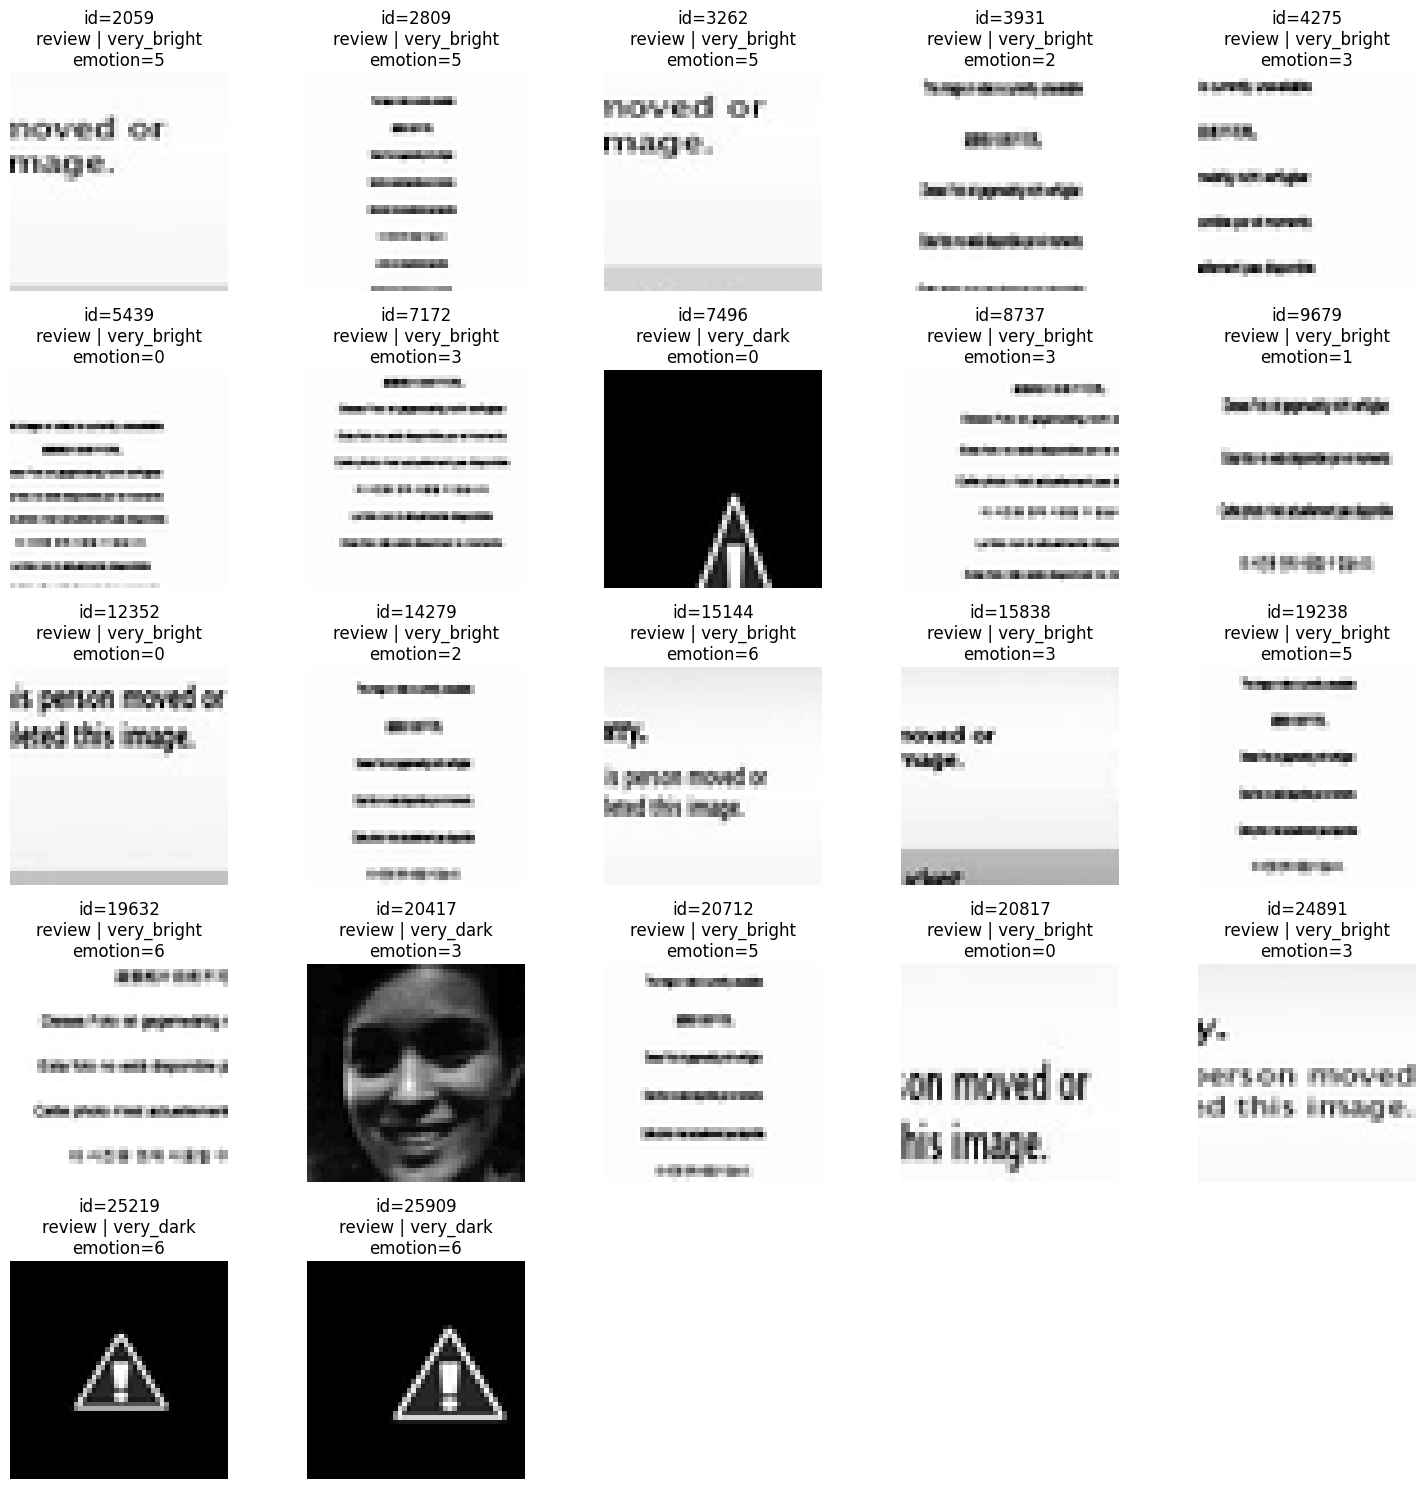

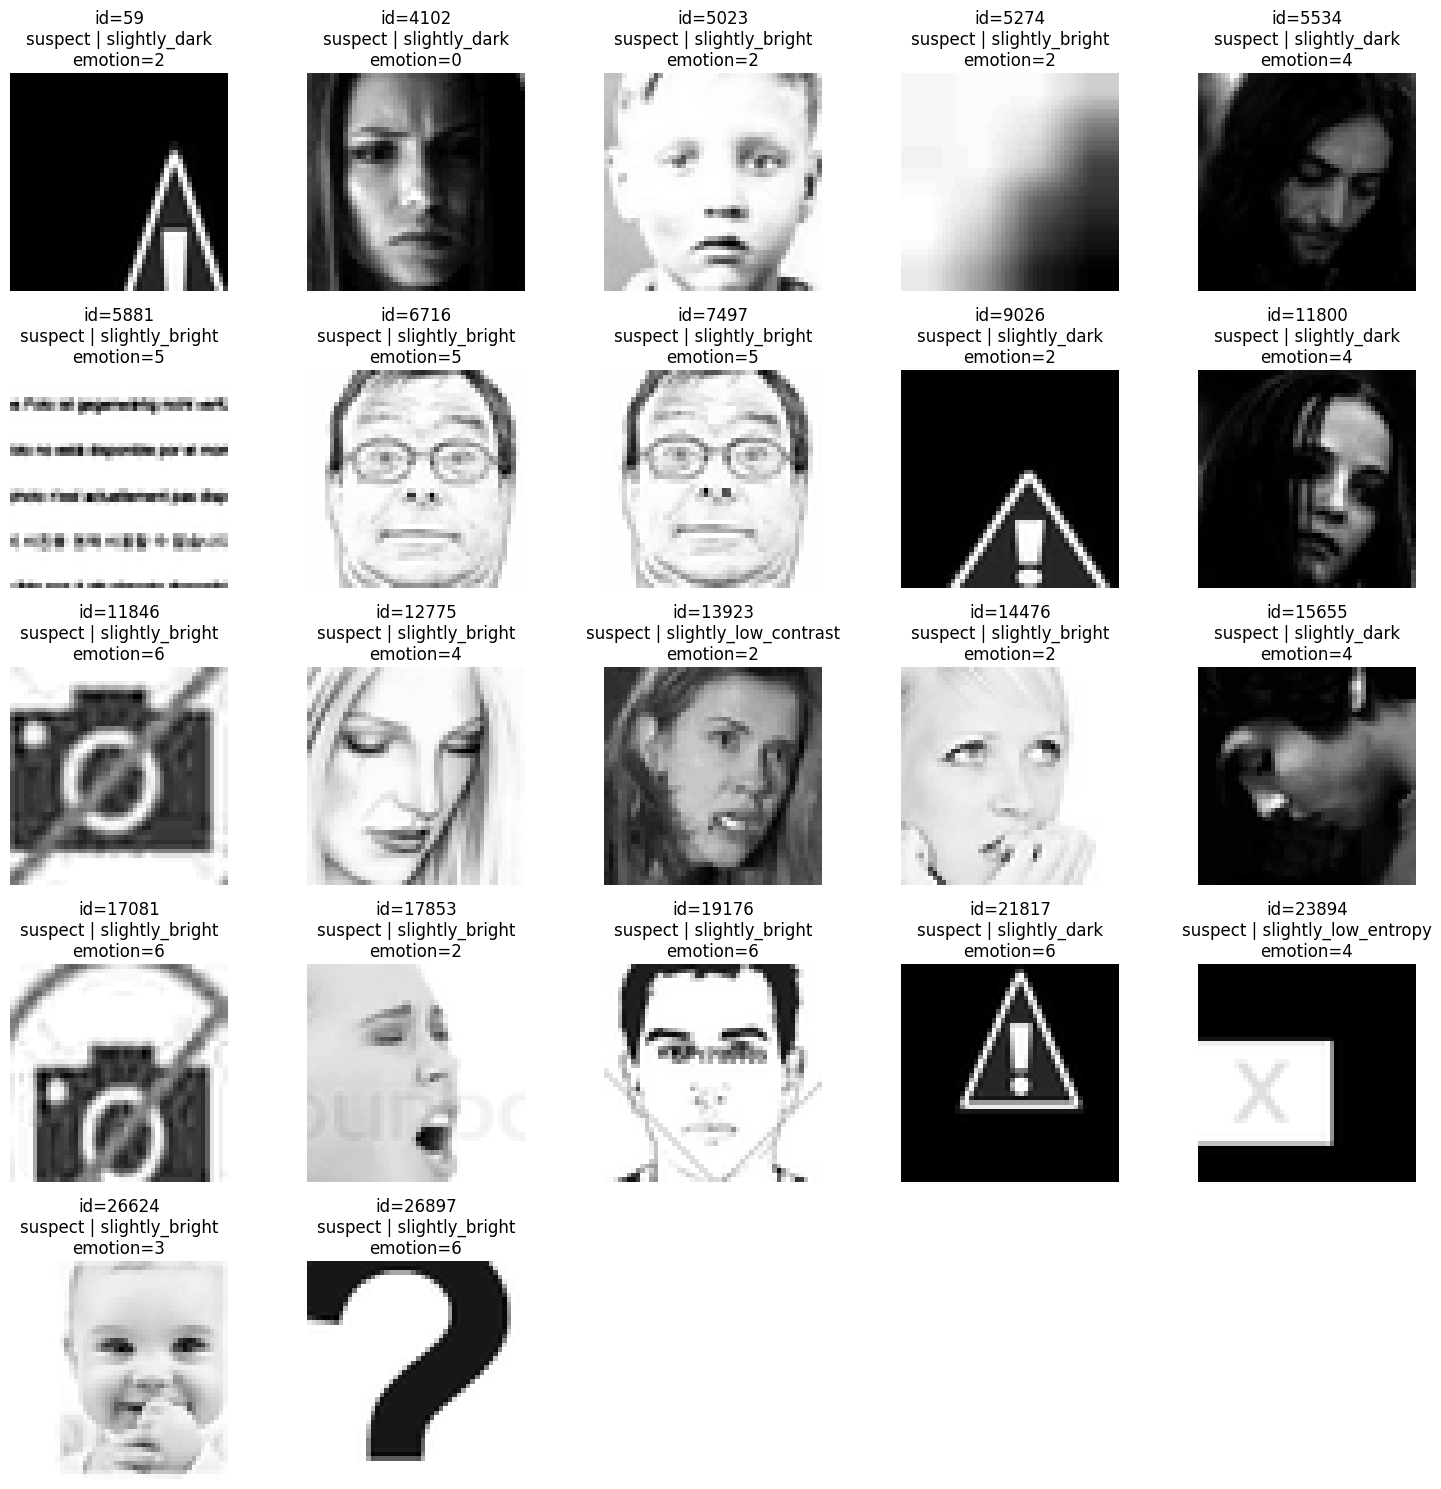

In [142]:
show_flagged_images(scan_df, label='remove', n=50)
show_flagged_images(scan_df, label='review', n=50)
show_flagged_images(scan_df, label='suspect', n=50)


## 12. Hàm xem 1 ảnh cụ thể theo row_id

In [143]:
def show_image_by_row_id(dataframe, row_id):
    row = dataframe[dataframe['row_id'] == row_id]
    if len(row) == 0:
        print('Không tìm thấy row_id:', row_id)
        return

    row = row.iloc[0]
    arr = parse_pixels_fast(row['pixels'])

    if len(arr) != PIXEL_COUNT:
        print('Ảnh sai số lượng pixel:', len(arr))
        return

    img = arr.reshape(IMAGE_SIZE, IMAGE_SIZE)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(
        f"row_id={row['row_id']}, emotion={row['emotion']}, Usage={row['Usage']}\nflag={row['flag']}, reason={row['reason']}"
    )
    plt.axis('off')
    plt.show()


In [144]:
# Ví dụ:
# show_image_by_row_id(scan_df, 123)


## 13. Xuất bản CSV đầy đủ

Cột xuất ra đúng theo yêu cầu:
`row_id, emotion, Usage, flag, reason, pixel_count, mean, std, min, max, unique_count, zero_ratio, white_ratio, entropy`


In [145]:
error_data = scan_df[scan_df['flag'] != 'ok'][[
    'row_id', 'emotion', 'Usage', 'flag', 'reason',
    'pixel_count', 'mean', 'std', 'min', 'max',
    'unique_count', 'zero_ratio', 'white_ratio', 'entropy'
]].copy()

error_export_path = Path(OUTPUT_DIR) / 'scan_error_flags.csv'
error_data.to_csv(error_export_path, index=False)

print('Đã lưu:', error_export_path)
display(error_data.head())

full_export_df = scan_df[[
    'row_id', 'emotion', 'Usage', 'flag', 'reason',
    'pixel_count', 'mean', 'std', 'min', 'max',
    'unique_count', 'zero_ratio', 'white_ratio', 'entropy'
]].copy()

full_export_path = Path(OUTPUT_DIR) / 'scan_full_flags.csv'
full_export_df.to_csv(full_export_path, index=False)

print('Đã lưu:', full_export_path)
display(full_export_df.head())



Đã lưu: ..\..\data\cleaned_data\scan_error_flags.csv


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy
59,59,2,Training,suspect,slightly_dark,2304,22.118924,61.149661,0,255,153,0.759983,0.023003,2.238288
2059,2059,5,Training,review,very_bright,2304,245.425781,21.609312,86,255,122,0.000000,0.051215,3.504083
2171,2171,6,Training,remove,very_low_std,2304,128.302951,0.637561,127,130,4,0.000000,0.000000,1.395017
2809,2809,5,Training,review,very_bright,2304,248.087240,17.691603,151,255,86,0.000000,0.118056,2.207127
3262,3262,5,Training,review,very_bright,2304,242.844618,23.055078,85,255,123,0.000000,0.057726,3.820714


Đã lưu: ..\..\data\cleaned_data\scan_full_flags.csv


,row_id,emotion,Usage,flag,reason,pixel_count,mean,std,min,max,unique_count,zero_ratio,white_ratio,entropy
0,0,0,Training,ok,ok,2304,117.592882,50.735357,11,210,190,0.000000,0.000000,7.316994
1,1,0,Training,ok,ok,2304,126.971354,40.854364,0,219,214,0.001736,0.000000,7.231241
2,2,2,Training,ok,ok,2304,160.814236,74.711745,0,255,254,0.015625,0.009549,7.670950
3,3,4,Training,ok,ok,2304,130.503472,59.357461,12,235,214,0.000000,0.000000,7.327695
4,4,6,Training,ok,ok,2304,97.900174,70.166311,0,241,234,0.077257,0.000000,7.488916


## 14. Xuất bản CSV rút gọn để bạn xóa thủ công

File này ban đầu sẽ chứa toàn bộ các dòng bị gắn cờ:
- `remove`
- `review`
- `suspect`

Tức là **không chứa `ok`**.

Sau đó bạn mở file này và:
- xóa những dòng bạn muốn giữ lại
- giữ lại những dòng bạn quyết định loại thật sự

Khi train, bạn chỉ cần đọc file này để lấy danh sách `row_id` cần bỏ.


In [146]:
manual_remove_candidate_df = scan_df[scan_df['flag'] != 'ok'][[
    'row_id', 'emotion', 'Usage'
]].copy()

manual_remove_candidate_path = Path(OUTPUT_DIR) / 'manual_remove_candidates.csv'
manual_remove_candidate_df.to_csv(manual_remove_candidate_path, index=False)

print('Đã lưu:', manual_remove_candidate_path)
display(manual_remove_candidate_df.head())


Đã lưu: ..\..\data\cleaned_data\manual_remove_candidates.csv


,row_id,emotion,Usage
59,59,2,Training
2059,2059,5,Training
2171,2171,6,Training
2809,2809,5,Training
3262,3262,5,Training


## 15. Ví dụ cách dùng file CSV rút gọn khi train

Ý tưởng:
- bạn giữ file gốc nguyên vẹn
- bạn chỉnh tay `manual_remove_candidates.csv`
- file đó sau khi chỉnh xong sẽ chỉ còn các dòng muốn remove
- lúc train chỉ cần bỏ các `row_id` nằm trong file đó


In [147]:
def load_row_ids_to_remove(path):
    remove_df = pd.read_csv(path)
    required_cols = {'row_id', 'emotion', 'Usage'}
    missing = required_cols - set(remove_df.columns)
    if missing:
        raise ValueError(f'Thiếu cột trong file remove list: {missing}')
    return set(remove_df['row_id'].astype(int).tolist())

# Ví dụ:
# final_remove_ids = load_row_ids_to_remove(manual_remove_candidate_path)
# train_df = load_data(DATA_PATH)
# train_df_filtered = train_df[~train_df['row_id'].isin(final_remove_ids)].reset_index(drop=True)
# print(len(train_df), '->', len(train_df_filtered))
